# Evaporative Cooling — 3D Box Potential  (N, Ω) formulation

Semiclassical simulation using the **(N, Ω)** recurrence pair instead of (N, E).

The density of states scales as $g(\varepsilon) \propto \varepsilon^{1/2}$, giving
polylogarithm orders $s_N = 3/2$ (particle number) and $s_\Omega = 5/2$ (grand
potential).  Temperature exponent of $C(T)$: $p = 3/2$.

**Reference:** Arvizu-Velázquez *et al.*, “Semi-classical evaporative cooling” (2026);
Poveda-Cuevas, “Semiclassical distribution for Bosons” (2026).

In [1]:
import numpy as np
import mpmath as mp
import time
from matplotlib import pyplot as plt

from evap_cool_utils_omega import (
    ConstantsSI,
    g_tilde, g_bar,
    newton_raphson_1var,
    mb_particle_number, mb_temperature_box,
    create_omega_result_dict, create_mb_result_dict,
    build_cutoff_schedule, initialize_omega_state, initialize_mb_state,
    run_quantum_evaporation_omega, run_mb_evaporation,
    compute_initial_omega,
    make_truncated_NOmega, make_nr_solver_omega, make_eos_energy,
    plot_combined_overview, plot_individual_panels,
    plot_omega_vs_energy_comparison,
)

## 1. Physical Parameters

In [2]:
# Physical constants (SI)
h  = ConstantsSI.h
hb = ConstantsSI.hbar
kB = ConstantsSI.kB
m  = ConstantsSI.m_Na23

# Trap parameters
V  = 6e-9   # Effective volume parameter

# Initial thermodynamic state
N0 = 1e7                   # Initial number of atoms
T0 = 5e-5                  # Initial temperature [K] = 50 μK

## 2. Equation of State

In [3]:
def thermal_wavelength(T):
    return mp.sqrt(h**2 / (2 * mp.pi * m * kB * T))

def dos_prefactor(T):
    lam = thermal_wavelength(T)
    return V / lam**3

# --- Boson equations for initial mu ---
def N_equation_boson(x):
    return dos_prefactor(T0) * mp.polylog(3/2, mp.exp(x)) - N0

def dN_equation_boson(x):
    return dos_prefactor(T0) * mp.polylog(1/2, mp.exp(x))

# --- Fermion equations for initial mu ---
def N_equation_fermion(x):
    return -dos_prefactor(T0) * mp.polylog(3/2, -mp.exp(x)) - N0

def dN_equation_fermion(x):
    return -dos_prefactor(T0) * mp.polylog(1/2, -mp.exp(x))

## 3. Compute Initial Chemical Potentials & Ω₀

In [4]:
# Polylogarithm orders for the 3D box
s_N = 3/2;  s_gbar_N = 1
s_Omega = 5/2;  s_gbar_Omega = 2
p_exp = 3/2;  nu_half = 3/2

# --- Bosons ---
start = time.time()
alpha_b = newton_raphson_1var(N_equation_boson, dN_equation_boson,
                              -15.5, -15, dx=1e-5)
if alpha_b is None:
    raise RuntimeError("Root not found for boson chemical potential")
mu0_b = alpha_b * kB * T0
Omega0_b = compute_initial_omega(+1, kB, T0, float(dos_prefactor(T0)), s_Omega, alpha_b)
E0_b = float((3/2) * N0 * kB * T0 * (
    mp.polylog(5/2, mp.exp(alpha_b)) / mp.polylog(3/2, mp.exp(alpha_b))
))
print(f"Bosons:   alpha = {alpha_b:.6f},  mu = {mu0_b:.6e}")
print(f"          Omega0 = {Omega0_b:.6e},  E0 = {E0_b:.6e}  [{time.time()-start:.1f}s]")

# --- Fermions ---
start = time.time()
alpha_f = newton_raphson_1var(N_equation_fermion, dN_equation_fermion,
                              -15.5, -15, dx=1e-5)
if alpha_f is None:
    raise RuntimeError("Root not found for fermion chemical potential")
mu0_f = alpha_f * kB * T0
Omega0_f = compute_initial_omega(-1, kB, T0, float(dos_prefactor(T0)), s_Omega, alpha_f)
E0_f = float((3/2) * N0 * kB * T0 * (
    mp.polylog(5/2, -mp.exp(alpha_f)) / mp.polylog(3/2, -mp.exp(alpha_f))
))
print(f"Fermions: alpha = {alpha_f:.6f},  mu = {mu0_f:.6e}")
print(f"          Omega0 = {Omega0_f:.6e},  E0 = {E0_f:.6e}  [{time.time()-start:.1f}s]")

Bosons:   alpha = -15.295863,  mu = -1.055911e-26
          Omega0 = -6.903242e-21,  E0 = 1.035486e-20  [2.2s]
Fermions: alpha = -15.295863,  mu = -1.055911e-26
          Omega0 = -6.903243e-21,  E0 = 1.035486e-20  [2.3s]


## 4. Build Cut-off Schedule & Initialize Data

In [5]:
Q0 = 5e-4
dQ = 1e-8
N_STEPS = 10000
dT_nr  = T0 * 1e-12           # ~ 5e-17
dmu_nr = abs(mu0_b) * 1e-12   # ~ 1e-38
Q_schedule = build_cutoff_schedule(Q0, dQ, N_STEPS)

results_b  = create_omega_result_dict()
results_f  = create_omega_result_dict()
results_mb = create_mb_result_dict()

initialize_omega_state(results_b, N0, T0, mu0_b, Omega0_b, E0_b)
initialize_omega_state(results_f, N0, T0, mu0_f, Omega0_f, E0_f)
initialize_mb_state(results_mb, N0, T0)

results_b['Q'] = Q_schedule; results_f['Q'] = Q_schedule; results_mb['Q'] = Q_schedule

## 5. Fused Truncated Distribution Functions (N, Ω)

For the 3D box, the recurrences are:

$$\frac{N_1}{N_0} = \frac{\tilde{g}_{3/2}}{g_{3/2}}
  - \frac{2}{\sqrt{\pi}}\,\eta_c^{1/2}\,\frac{\bar{g}_{1}}{g_{3/2}}$$

$$\frac{\Omega_1}{\Omega_0} = \frac{\tilde{g}_{5/2}}{g_{5/2}}
  - \frac{2}{\sqrt{\pi}}\,\eta_c^{1/2}\,\frac{\bar{g}_{2}}{g_{5/2}}$$

In [6]:
truncated_NOmega_boson_box = make_truncated_NOmega(
    sign=+1, s_N=s_N, s_gbar_N=s_gbar_N,
    s_Omega=s_Omega, s_gbar_Omega=s_gbar_Omega, kB=kB)

truncated_NOmega_fermion_box = make_truncated_NOmega(
    sign=-1, s_N=s_N, s_gbar_N=s_gbar_N,
    s_Omega=s_Omega, s_gbar_Omega=s_gbar_Omega, kB=kB)

## 6. Newton–Raphson (2-Variable) Solver for (N, Ω)

In [7]:
nr_solver_boson_box = make_nr_solver_omega(
    sign=+1, s_N=s_N, s_Omega=s_Omega, p_exp=p_exp,
    dos_prefactor_func=dos_prefactor, kB=kB)

nr_solver_fermion_box = make_nr_solver_omega(
    sign=-1, s_N=s_N, s_Omega=s_Omega, p_exp=p_exp,
    dos_prefactor_func=dos_prefactor, kB=kB)

## 7. Run Evaporation Simulations

In [8]:
# Optional: back-compute E from EOS for comparison
eos_energy_boson = make_eos_energy(+1, s_N, s_Omega, nu_half, kB)
eos_energy_fermion = make_eos_energy(-1, s_N, s_Omega, nu_half, kB)

print("Running boson evaporation (N, Omega)...")
start = time.time()
run_quantum_evaporation_omega(results_b, truncated_NOmega_boson_box,
                              nr_solver_boson_box, N0, N_STEPS, dT_nr, dmu_nr,
                              eos_energy_func=eos_energy_boson)
print(f"  Done in {time.time()-start:.1f}s")

print("Running fermion evaporation (N, Omega)...")
start = time.time()
run_quantum_evaporation_omega(results_f, truncated_NOmega_fermion_box,
                              nr_solver_fermion_box, N0, N_STEPS, dT_nr, dmu_nr,
                              eos_energy_func=eos_energy_fermion)
print(f"  Done in {time.time()-start:.1f}s")

print("Running Maxwell-Boltzmann evaporation...")
start = time.time()
run_mb_evaporation(results_mb, mb_particle_number, mb_temperature_box, N0, N_STEPS)
print(f"  Done in {time.time()-start:.1f}s")

Running boson evaporation (N, Omega)...
  Done in 28.4s
Running fermion evaporation (N, Omega)...
  Done in 28.4s
Running Maxwell-Boltzmann evaporation...
  Done in 0.1s


## 8. Results

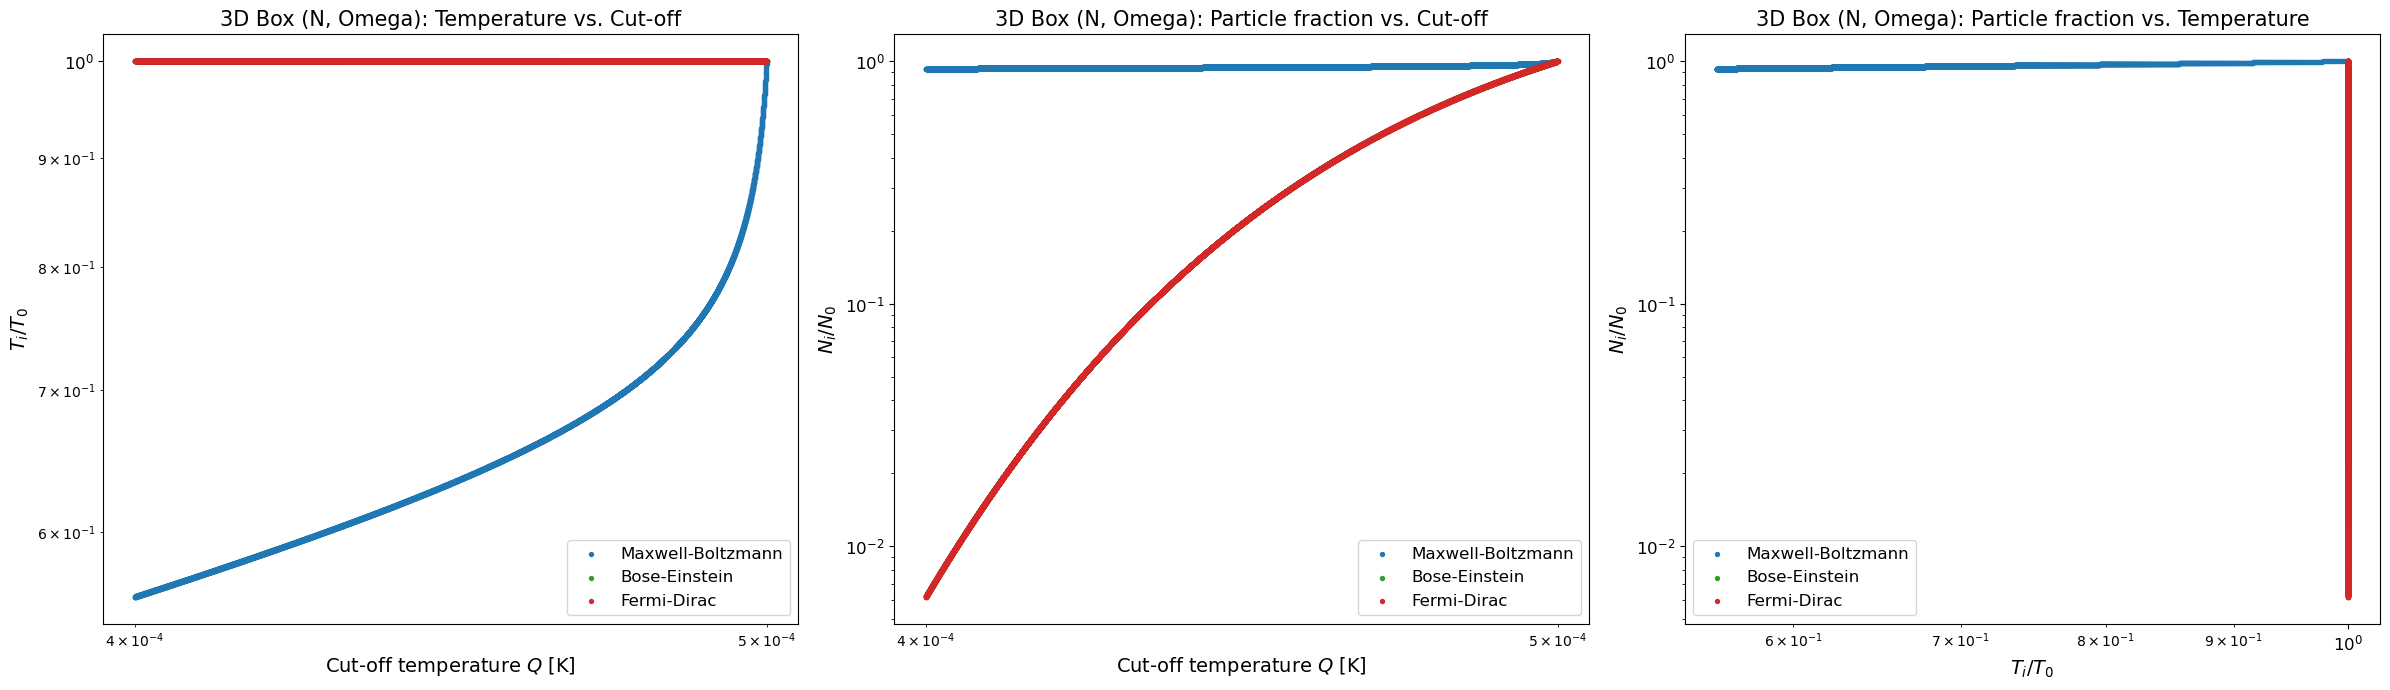

In [9]:
fig = plot_combined_overview(results_b, results_f, results_mb, "3D Box (N, Omega)")
plt.show()

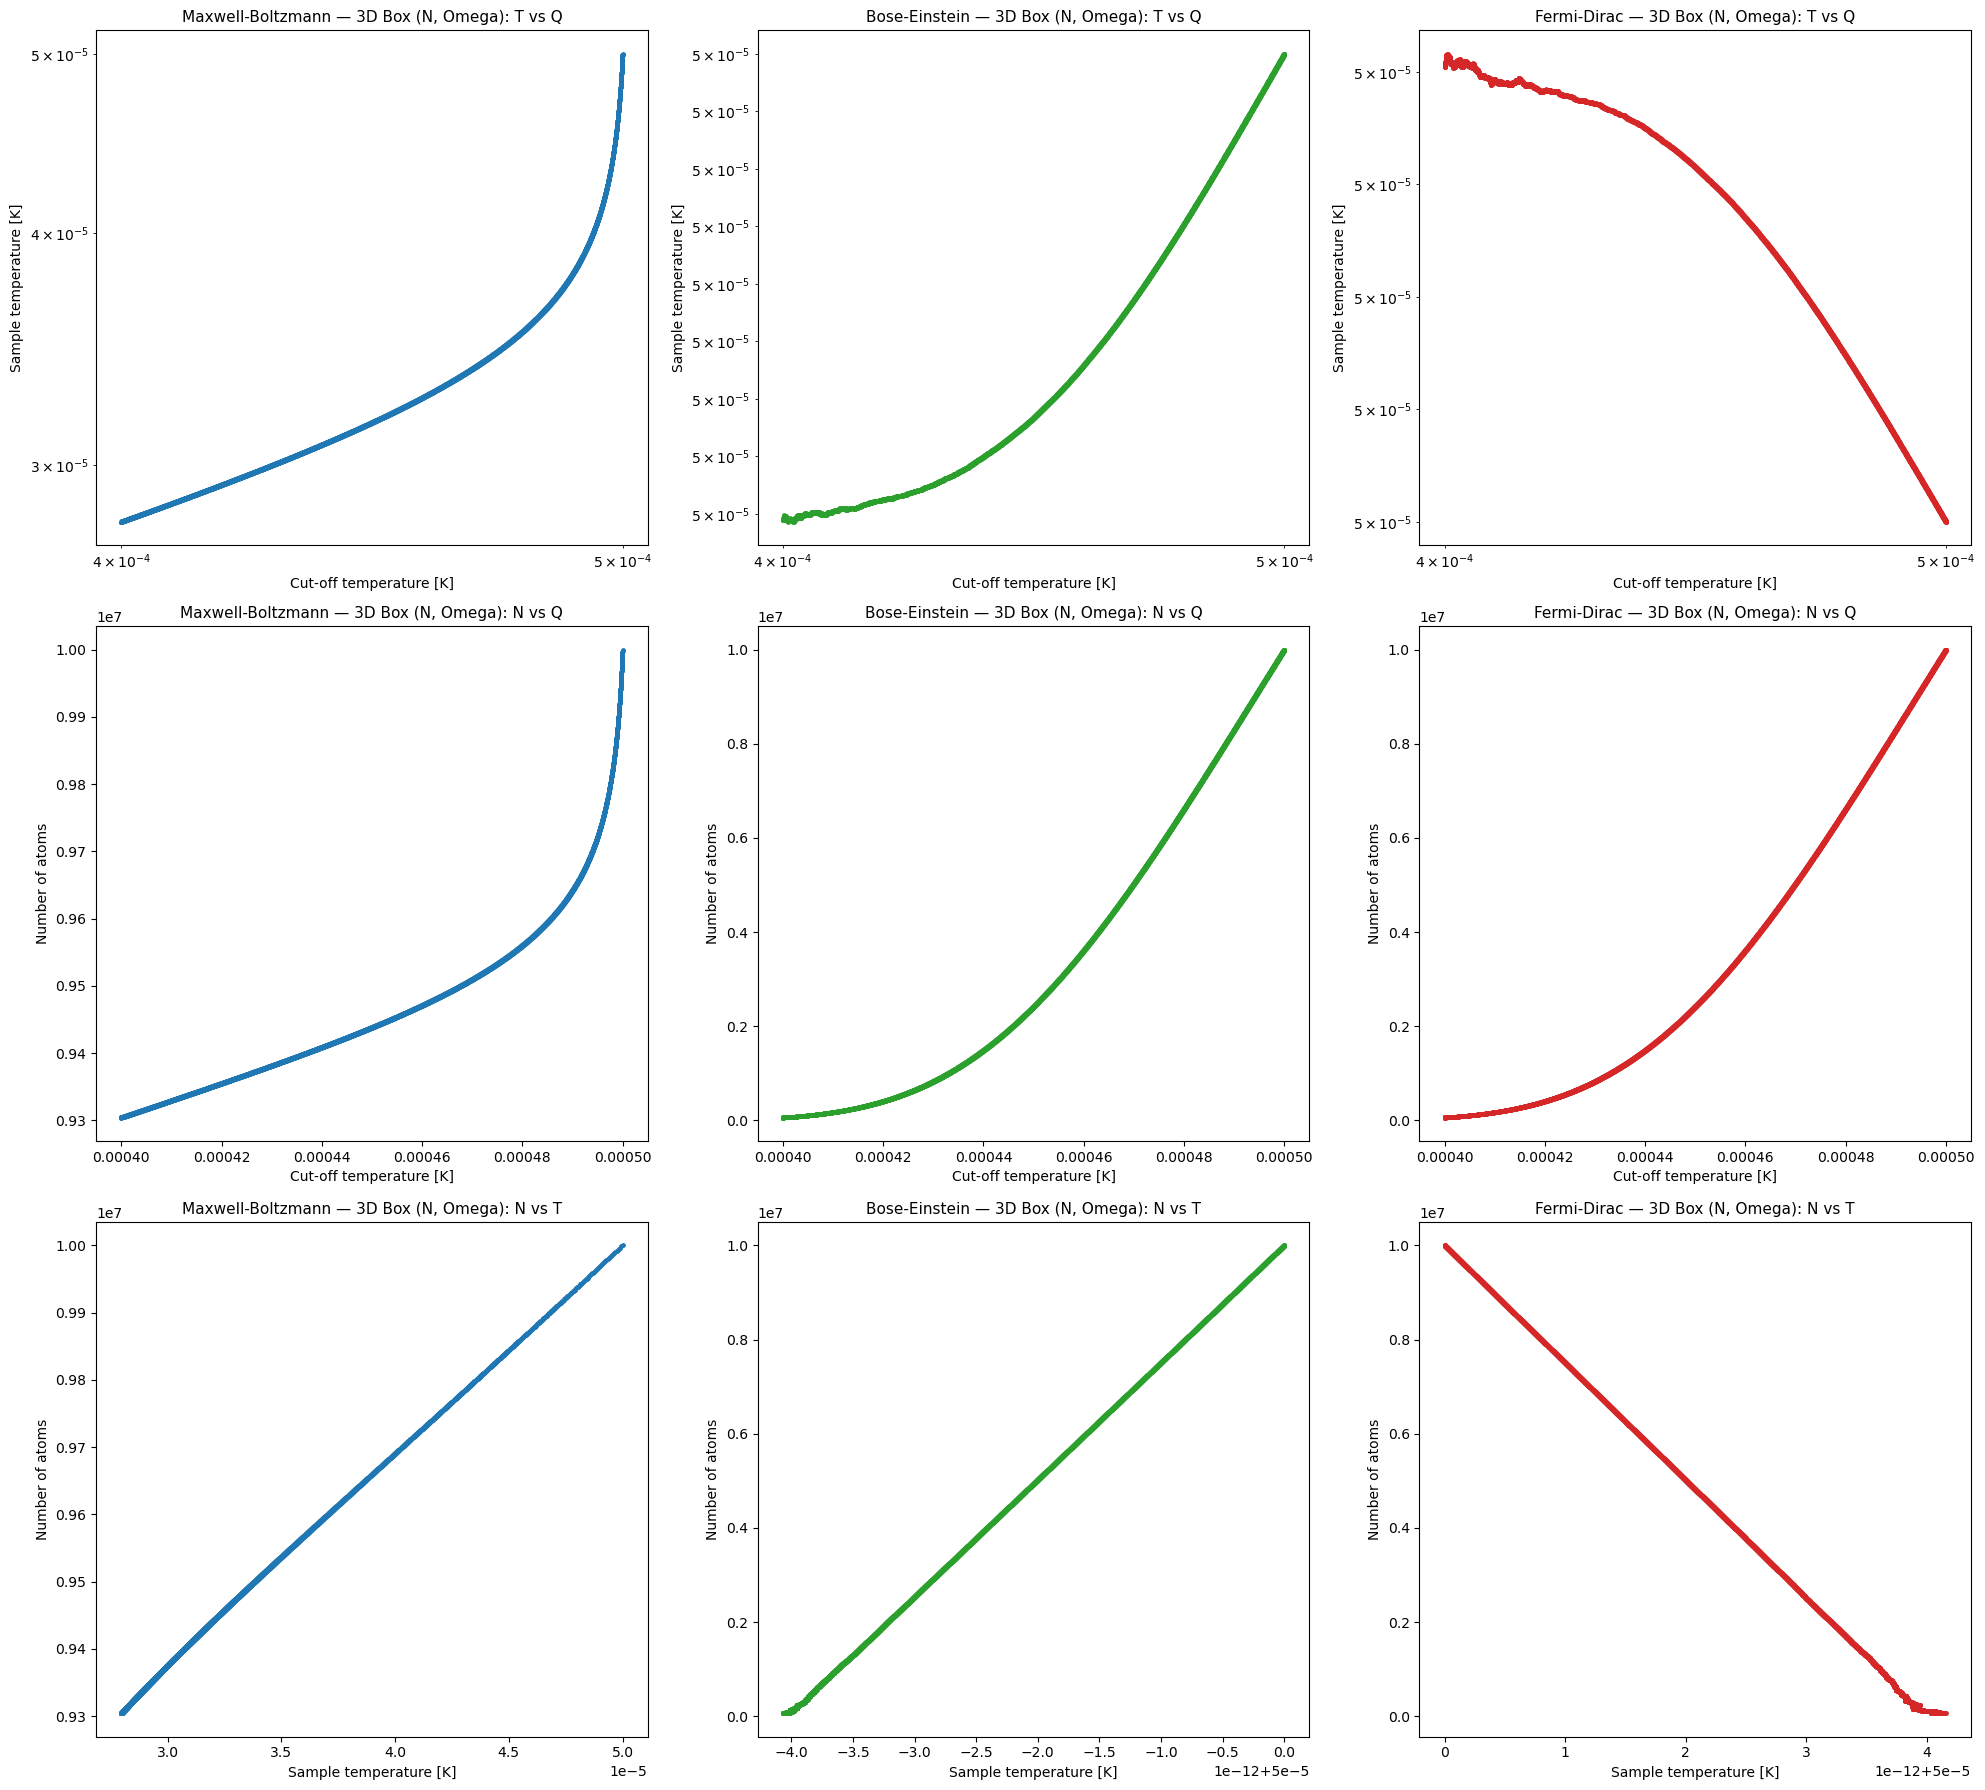

In [10]:
fig = plot_individual_panels(results_b, results_f, results_mb, "3D Box (N, Omega)")
plt.show()